# Matematik Pintar SPM - Sistem Pembelajaran Adaptif Matematik Tingkatan 4 dan 5 Menggunakan Teknik Pembelajaran Mesin (ML)

Nama : Marsya Aneesa binti Md Jamil@Md Shahril

No. Matriks : A203922

CS-DS

## PENTING: Model Digabungkan Menjadi SATU (ExamBand + SHAP) — Perlu Dijalankan Semula

Notebook ini telah dikemas kini lagi berikutan siasatan lanjut:

1. **Pembetulan kebocoran data (SMOTE/cross-validation)** dan **kalibrasi kebarangkalian** -- sudah dibetulkan sebelum ini, kekal tidak berubah.
2. **ExamScore kini digunakan semula**, tetapi dalam bentuk **ExamBand** -- 4 jalur kasar (<=40, 41-60, 61-80, 81-100), bukan nilai tepat 0-100 dan bukan dikecualikan sepenuhnya. Menggunakan ExamScore terus menyebabkan model menjadi carian remeh (~100% ketepatan); mengecualikannya sepenuhnya (percubaan awal) menyebabkan model tidak stabil -- ujian kepekaan dan analisis SHAP mendapati perubahan kecil pada satu ciri tingkah laku sahaja boleh menyebabkan ramalan bertukar sepenuhnya. Pengumpulan kepada jalur kasar menyelesaikan kedua-dua masalah sekali gus.
3. **Analisis SHAP** (Bahagian 17.2, baharu) ditambah untuk mengesahkan sumbangan setiap ciri kepada ramalan model akhir, melengkapi kepentingan ciri Random Forest yang sedia ada.

**Hanya SATU model Hibrid RF-DNN wujud dalam projek ini sekarang** -- model yang dilatih di sini digunakan terus oleh `app.py` untuk penempatan pelajar sebenar, tanpa model deployment berasingan.

Ketepatan ujian (test accuracy) yang jujur untuk model akhir ini ialah **~90-91%**, dan gelagatnya disahkan stabil (Bahagian 17.1).

**Semua sel kod di bawah perlu dijalankan semula (Run All) di Google Colab** supaya output, jadual dan graf mencerminkan kod yang telah dikemas kini. Output sedia ada telah dikosongkan untuk mengelakkan kekeliruan dengan keputusan lama.


In [ ]:
!pip -q install imbalanced-learn openpyxl joblib pandas numpy scipy matplotlib seaborn scikit-learn shap


In [ ]:
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
    cross_val_score, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

try:
    import sklearn
    print("scikit-learn version:", sklearn.__version__)
except Exception:
    sklearn = None

RANDOM_STATE = 42

LEVEL_ENCODING = {"Rendah": 0, "Sederhana": 1, "Tinggi": 2}
LEVEL_DECODING = {0: "Rendah", 1: "Sederhana", 2: "Tinggi"}

# ExamScore never goes below 40 in this dataset (Rendah's true range is 40-54), so a band edge
# below 40 would have zero training examples -- a real user entering a low score would hit an
# unseen one-hot category and the model would fall back on other features. The lowest band's
# upper edge is therefore 40, not a smaller number.
EXAM_BAND_EDGES = [-1, 40, 60, 80, 100]
EXAM_BAND_LABELS = [0, 1, 2, 3]


def exam_score_to_band(score):
    score = max(0.0, min(100.0, float(score)))
    for i in range(len(EXAM_BAND_EDGES) - 1):
        if EXAM_BAND_EDGES[i] < score <= EXAM_BAND_EDGES[i + 1]:
            return EXAM_BAND_LABELS[i]
    return EXAM_BAND_LABELS[0]


os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


### 1. Upload Dataset

- student_performance.csv
- Bank Soalan.xlsx

Dataset prestasi pelajar digunakan untuk proses latihan model.
Bank soalan disemak dalam notebook ini bagi memastikan fail tersebut lengkap dan sesuai digunakan dalam modul kuiz Streamlit.

In [ ]:
from google.colab import files
uploaded = files.upload()

STUDENT_PATH = None
QUESTION_PATH = None

for filename in uploaded.keys():
    lower = filename.lower()
    if lower.endswith(".csv") and "student" in lower:
        STUDENT_PATH = filename
    if lower.endswith((".xlsx", ".xls")) and ("bank" in lower or "soalan" in lower or "question" in lower):
        QUESTION_PATH = filename

print("Student dataset:", STUDENT_PATH)
print("Question bank:", QUESTION_PATH)

if STUDENT_PATH is None:
    raise FileNotFoundError("Please upload student_performance.csv.")
if QUESTION_PATH is None:
    print("Question bank was not found. Model training can still continue, but question bank validation will be skipped.")


Saving Bank Soalan.xlsx to Bank Soalan.xlsx
Saving student_performance.csv to student_performance.csv
Student dataset: student_performance.csv
Question bank: Bank Soalan.xlsx


### 2. Load Dataset




In [ ]:
df_student_raw = pd.read_csv(STUDENT_PATH)
print("Raw student dataset shape:", df_student_raw.shape)
display(df_student_raw.head())

print("Data types:")
print(df_student_raw.dtypes)


def load_question_bank(path):
    if path is None:
        return pd.DataFrame()

    preview = pd.read_excel(path, header=None)
    header_row = None
    expected_markers = {"QuestionID", "Topic", "Difficulty", "QuestionText"}

    for i in range(len(preview)):
        row_values = set(preview.iloc[i].astype(str).str.strip().tolist())
        if len(expected_markers.intersection(row_values)) >= 3:
            header_row = i
            break

    if header_row is None:
        dfq = pd.read_excel(path)
    else:
        dfq = pd.read_excel(path, header=header_row)

    dfq = dfq.dropna(how="all").copy()
    dfq.columns = [str(c).strip() for c in dfq.columns]
    return dfq


df_questions_raw = load_question_bank(QUESTION_PATH)
print("Question bank shape:", df_questions_raw.shape)
if not df_questions_raw.empty:
    display(df_questions_raw.head())


Raw student dataset shape: (14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


Data types:
StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech                 int64
StressLevel             int64
FinalGrade              int64
dtype: object
Question bank shape: (505, 11)


,QuestionID,Topic,Difficulty,QuestionText,OptionA,OptionB,OptionC,OptionD,CorrectAnswer,Hint,MaxTime
0,1,Angka Bererti,Rendah,Bundarkan 0.3768 betul kepada dua angka berert...,0.30,0.38,0.37,0.40,B,"Lihat angka ketiga; jika 5 atau lebih, tambah ...",60.0
1,2,Kuasa Dua & Punca Kuasa,Rendah,√16 * √16 * √16 =,√16,16,64,8,C,Selesaikan punca kuasa dua dahulu (√16= 4) kem...,60.0
2,3,"Nisbah, Kadar dan Kadaran",Rendah,Hani membeli 5kg durian dengan harga RM120. Be...,2,3,6,10,D,Cari harga untuk 1kg dahulu atau gunakan perka...,60.0
3,4,Persamaan Linear,Rendah,"Antara berikut, yang manakah persamaan linear ...",x + 2 = 10,x - y = 12,2x = 5 +y,x = 2y,A,Persamaan linear dalam satu pemboleh ubah hany...,60.0
4,5,Rumus Algebra,Sederhana,Diberi bahawa x = 2-y/1+3y. Ungkapkan y dalam ...,2+x/1+3x,z-2/3x+1,2-z/3x+1,3z+1/2-x,C,"Darab silang untuk menghapuskan pecahan, kemud...",120.0


### 3. Pengesahan dan Pembersihan Bank Soalan

Bank soalan tidak digunakan untuk melatih model RF-DNN. Namun, bank soalan tetap disemak dalam bahagian ini kerana sistem yang dibangunkan memerlukan lajur tertentu untuk memastikan modul kuiz dapat dijalankan dengan betul.


In [ ]:
required_question_columns = [
    "QuestionID", "Topic", "Difficulty", "QuestionText",
    "OptionA", "OptionB", "OptionC", "OptionD", "CorrectAnswer"
]

if df_questions_raw.empty:
    print("Question bank was not uploaded. Skipping question bank validation.")
    df_questions = pd.DataFrame()
else:
    missing_required = [c for c in required_question_columns if c not in df_questions_raw.columns]
    if missing_required:
        raise ValueError(f"Missing required question bank columns: {missing_required}")

    df_questions = df_questions_raw.copy()
    df_questions = df_questions.dropna(subset=["QuestionText", "OptionA", "OptionB", "OptionC", "OptionD", "CorrectAnswer"])

    difficulty_map = {
        "rendah": "Rendah", "low": "Rendah",
        "sederhana": "Sederhana", "medium": "Sederhana", "intermediate": "Sederhana",
        "tinggi": "Tinggi", "high": "Tinggi"
    }
    df_questions["Difficulty"] = df_questions["Difficulty"].astype(str).str.strip().str.lower().map(difficulty_map)
    df_questions = df_questions.dropna(subset=["Difficulty"])
    df_questions["CorrectAnswer"] = df_questions["CorrectAnswer"].astype(str).str.strip().str.upper()

    if "Hint" not in df_questions.columns:
        df_questions["Hint"] = ""
    if "MaxTime" not in df_questions.columns:
        df_questions["MaxTime"] = 60

    df_questions["MaxTime"] = pd.to_numeric(df_questions["MaxTime"], errors="coerce").fillna(60).astype(int)

    print("Cleaned question bank shape:", df_questions.shape)
    print("Difficulty distribution:")
    display(df_questions["Difficulty"].value_counts().rename_axis("Difficulty").reset_index(name="Count"))

    print("Top topic distribution:")
    display(df_questions["Topic"].value_counts().rename_axis("Topic").reset_index(name="Count").head(20))


Cleaned question bank shape: (504, 11)
Difficulty distribution:


,Difficulty,Count
0,Sederhana,199
1,Rendah,196
2,Tinggi,109


Top topic distribution:


,Topic,Count
0,Matriks,42
1,Indeks,38
2,Asas Nombor,36
3,Ungkapan Algebra,35
4,Insurans,23
5,Matematik Pengguna,23
6,Bentuk Piawai,21
7,Kebarangkalian,20
8,Percukaian,18
9,Angka Bererti,18


### 4. Pembersihan Dataset Pelajar

Bahagian ini membuang rekod duplikasi dan menyemak nilai hilang sebelum proses pemodelan dijalankan. Langkah ini penting bagi memastikan data yang digunakan untuk latihan model berada dalam keadaan bersih dan sesuai.


In [ ]:
df = df_student_raw.copy()

print("Initial shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isna().sum().sum())


df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

expected_columns = [
    "StudyHours", "Attendance", "Resources", "Extracurricular", "Motivation",
    "Internet", "Gender", "Age", "LearningStyle", "OnlineCourses",
    "Discussions", "AssignmentCompletion", "ExamScore", "EduTech", "StressLevel", "FinalGrade"
]

missing_cols = [c for c in expected_columns if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected dataset columns: {missing_cols}")

print("Dataset columns are valid.")


Initial shape: (14003, 16)
Duplicate rows: 1534
Total missing values: 0
Shape after duplicate removal: (12469, 16)
Dataset columns are valid.


### 5. Analisis Penerokaan Data (EDA)
Analisis ini merangkumi statistik deskriptif, taburan kelas sasaran, visualisasi ciri utama dan peta haba korelasi.

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
StudyHours,12469.0,20.034405,6.049485,5.0,16.0,20.0,24.0,44.0
Attendance,12469.0,80.239233,11.469028,60.0,70.0,80.0,90.0,100.0
Resources,12469.0,1.101371,0.711171,0.0,1.0,1.0,2.0,2.0
Extracurricular,12469.0,0.583126,0.493061,0.0,0.0,1.0,1.0,1.0
Motivation,12469.0,0.907370,0.709599,0.0,0.0,1.0,1.0,2.0
Internet,12469.0,0.917074,0.275781,0.0,1.0,1.0,1.0,1.0
Gender,12469.0,0.538616,0.498527,0.0,0.0,1.0,1.0,1.0
Age,12469.0,23.529152,3.510956,18.0,20.0,24.0,27.0,29.0
LearningStyle,12469.0,1.515358,1.116071,0.0,1.0,2.0,3.0,3.0
OnlineCourses,12469.0,9.872404,6.114025,0.0,5.0,10.0,15.0,20.0


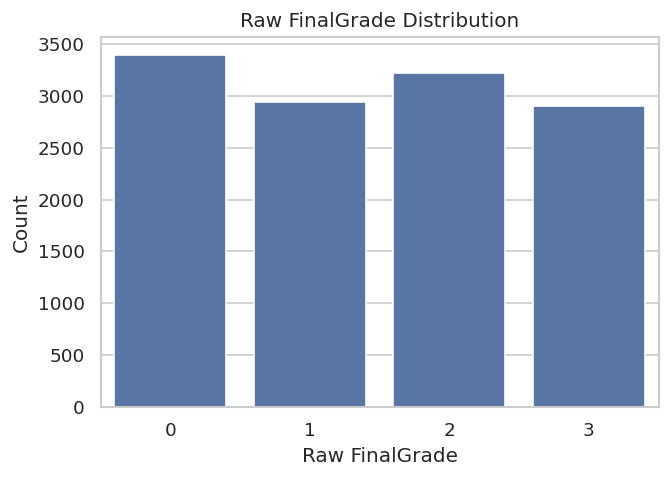

Raw FinalGrade counts:


,FinalGrade,Count
0,0,3401
1,1,2943
2,2,3221
3,3,2904


In [ ]:
print("Descriptive statistics:")
display(df.describe().T)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="FinalGrade", ax=ax)
ax.set_title("Raw FinalGrade Distribution")
ax.set_xlabel("Raw FinalGrade")
ax.set_ylabel("Count")
plt.show()

print("Raw FinalGrade counts:")
display(df["FinalGrade"].value_counts().sort_index().rename_axis("FinalGrade").reset_index(name="Count"))


### 5.1 Taburan Ciri Profil Pelajar

Graf dalam bahagian ini digunakan untuk melihat taburan ciri utama pelajar seperti jam belajar, kehadiran, motivasi, tahap stres, penyelesaian tugasan dan penggunaan teknologi. Tujuannya adalah untuk memastikan data yang digunakan masih munasabah sebelum digunakan dalam model.


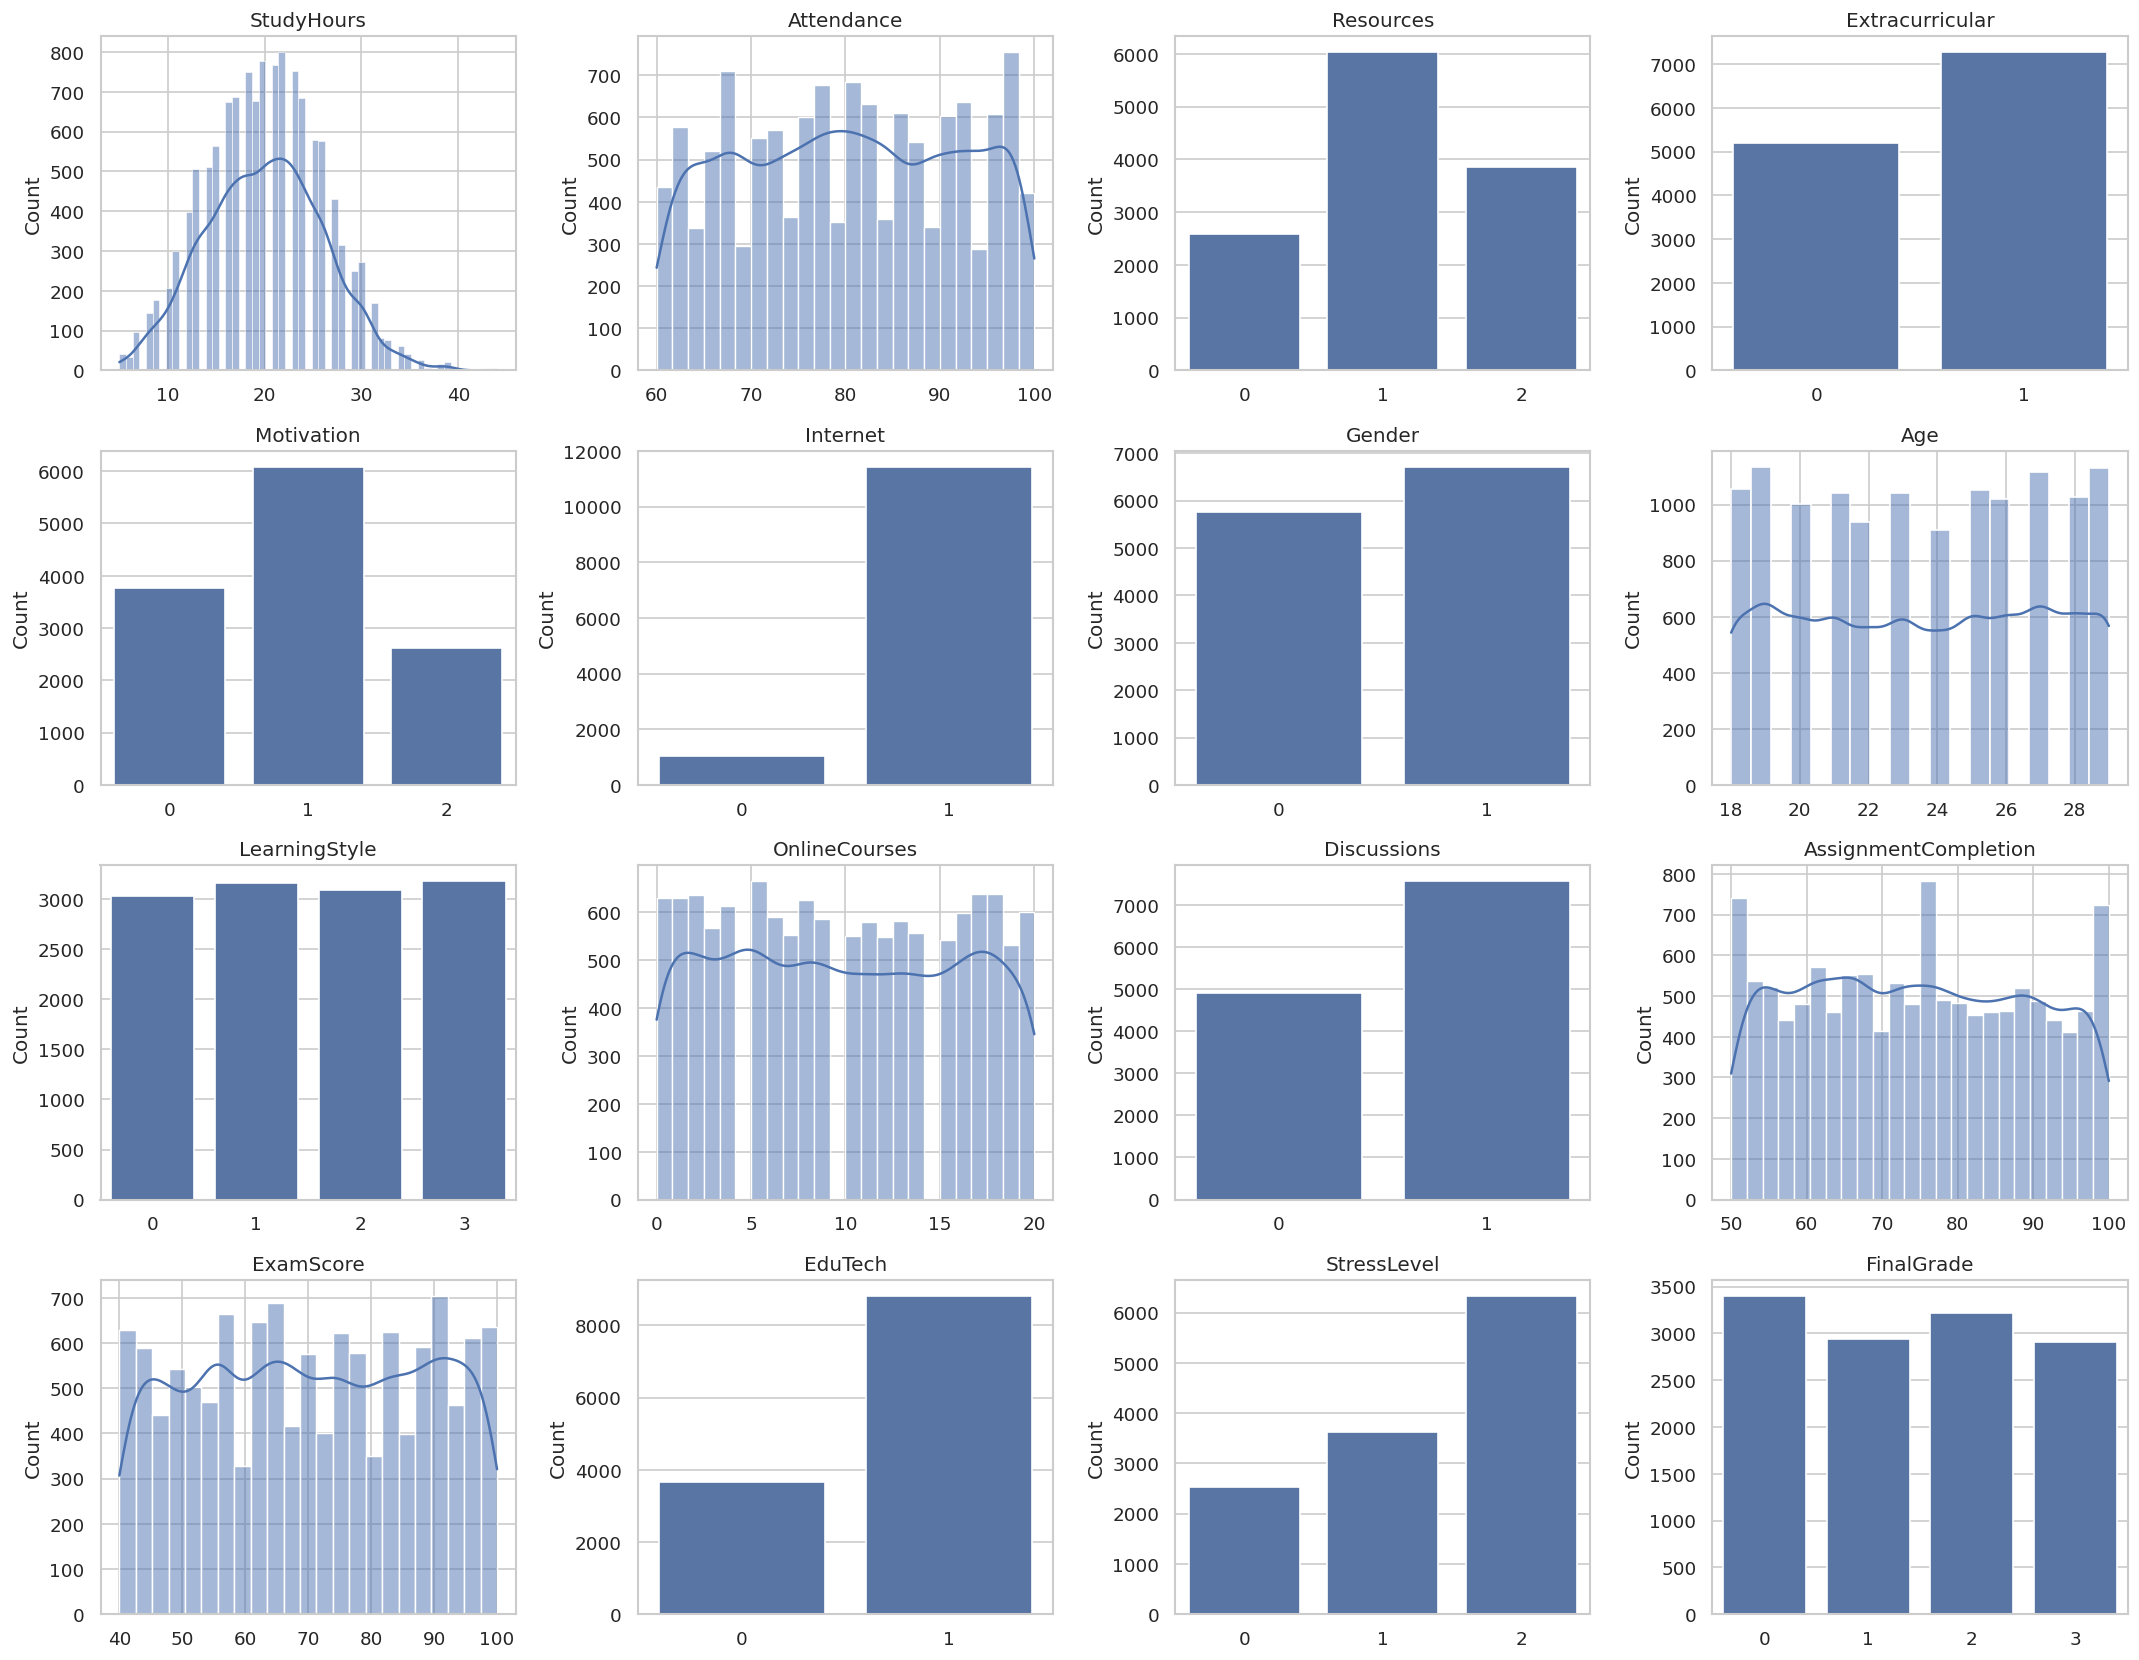

In [ ]:
# Features used for distribution checking
plot_cols = [
    "StudyHours", "Attendance", "Resources", "Extracurricular",
    "Motivation", "Internet", "Gender", "Age", "LearningStyle",
    "OnlineCourses", "Discussions", "AssignmentCompletion",
    "ExamScore", "EduTech", "StressLevel", "FinalGrade"
]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    if df[col].nunique() <= 10:
        sns.countplot(data=df, x=col, ax=ax)
    else:
        sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Hide unused empty plots
for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

###5.2 Peta Haba Korelasi

Nilai korelasi antara **ExamScore** dan **FinalGrade** adalah sekitar **-0.97**, yang menunjukkan hubungan yang sangat kuat. Nilai ini menjadi negatif kerana **FinalGrade** dalam dataset ini dikodkan secara songsang. Maksudnya, nilai **FinalGrade** yang lebih rendah mewakili prestasi yang lebih baik. Oleh itu, apabila **ExamScore** semakin tinggi, nilai mentah **FinalGrade** semakin rendah. Disebabkan hubungan ini terlalu kuat, **ExamScore** tidak digunakan secara terus (sebagai nilai tepat 0-100) dalam latihan model akhir -- ia dikumpulkan kepada jalur kasar terlebih dahulu (lihat Bahagian 5.3 dan 6).


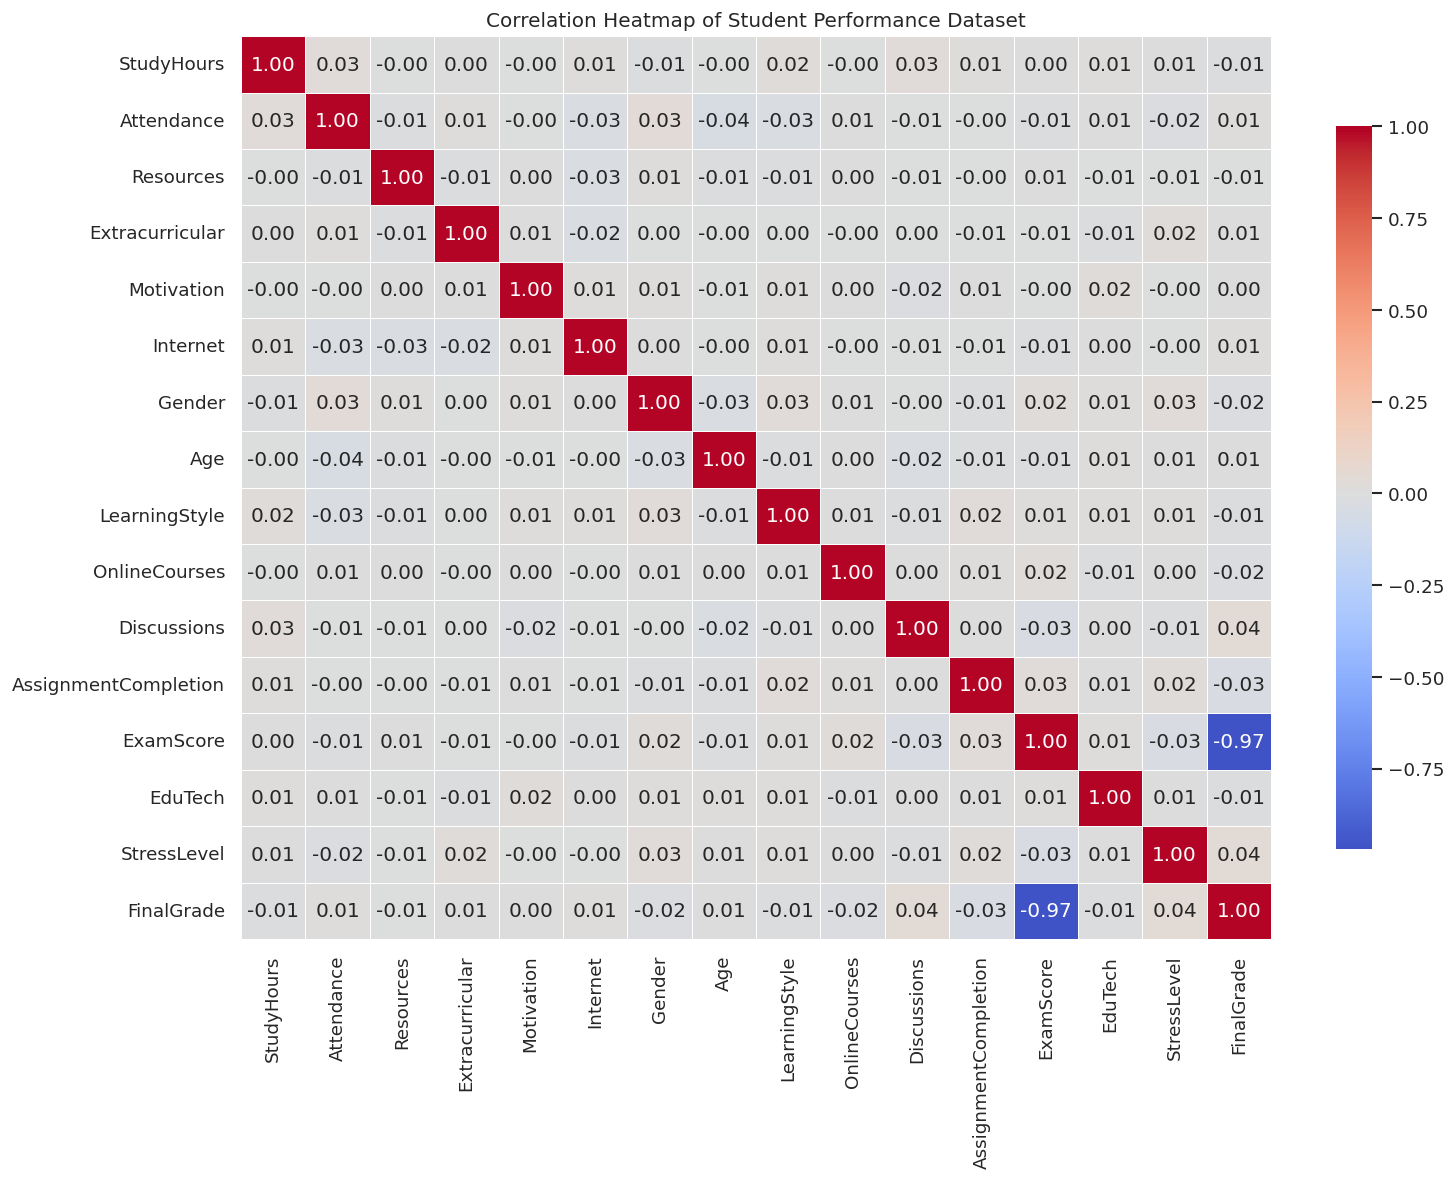

Saved: outputs/correlation_heatmap.png


In [ ]:
corr_df = df[expected_columns].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Student Performance Dataset")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Student Performance Dataset")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved: outputs/correlation_heatmap.png")


###5.3 Semakan Ciri ExamScore

Sebelum model akhir dilatih, ciri **ExamScore** disemak terlebih dahulu kerana ciri ini sangat berkait rapat dengan FinalGrade. Semasa eksperimen awal, dua pendekatan diuji:

1. **ExamScore digunakan terus (nilai tepat 0-100):** model menghasilkan keputusan yang terlalu tinggi dan hampir sempurna (~100% ketepatan), kerana ExamScore secara praktikalnya *menentukan* label -- tiada tindanan (overlap) antara julat ExamScore bagi setiap FinalGrade (lihat jadual di bawah). Ini menjadikan model sekadar carian (lookup), bukan pembelajaran sebenar daripada profil pelajar.
2. **ExamScore dikecualikan sepenuhnya:** model menjadi tidak stabil -- ujian kepekaan (Bahagian 17.1) dan analisis SHAP (Bahagian 17.2) menunjukkan perubahan kecil pada satu ciri sahaja (contohnya Kehadiran) boleh menyebabkan ramalan bertukar sepenuhnya antara Rendah, Sederhana dan Tinggi dengan keyakinan tinggi pada kedua-dua arah. Ini berlaku kerana tiada satu ciri profil pun (Jam Belajar, Kehadiran, Motivasi dan lain-lain) mempunyai korelasi bermakna dengan label (kesemuanya di bawah 0.04).

Penyelesaian yang digunakan dalam model akhir ialah mengumpulkan ExamScore kepada **4 jalur kasar** (skor <=40, 41-60, 61-80, 81-100) sebagai satu ciri kategori, bukan nilai tepat 0-100. Pendekatan ini mengekalkan isyarat sebenar dan kukuh daripada ExamScore, tetapi dua daripada empat jalur tersebut sengaja bertindih antara dua kelas kompetensi (lihat crosstab ExamBand di bawah), memberi ruang sebenar kepada ciri profil pembelajaran untuk turut menyumbang kepada keputusan akhir.


In [ ]:
score_grade_table = (
    df.groupby("FinalGrade")["ExamScore"]
    .agg(["min", "max", "mean", "median", "count"])
    .reset_index()
)

print("ExamScore summary by raw FinalGrade:")
display(score_grade_table)

# Check whether the same ExamScore can appear in more than one FinalGrade.
score_to_grade_count = df.groupby("ExamScore")["FinalGrade"].nunique()
overlapping_scores = int((score_to_grade_count > 1).sum())
print("Number of ExamScore values linked to more than one FinalGrade:", overlapping_scores)

corr_value = float(df["ExamScore"].corr(df["FinalGrade"]))
print("Correlation between ExamScore and raw FinalGrade:", round(corr_value, 4))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="FinalGrade", y="ExamScore", ax=ax)
ax.set_title("ExamScore Distribution by Raw FinalGrade")
ax.set_xlabel("Raw FinalGrade")
ax.set_ylabel("ExamScore")
plt.tight_layout()
plt.show()

# ExamScore is banded into 4 coarse categories rather than excluded or used as a precise
# value -- see the markdown note above for why.
df["ExamBand"] = df["ExamScore"].apply(exam_score_to_band)
print("\nExamBand vs raw FinalGrade crosstab:")
print(pd.crosstab(df["ExamBand"], df["FinalGrade"]).to_string())


###5.4 Pemetaan FinalGrade kepada Tahap Pelajar

Sistem ini menggunakan tiga tahap pelajar sebagai output model:

- 0 = Rendah
- 1 = Sederhana
- 2 = Tinggi

Label asal dalam dataset ialah FinalGrade. Label ini dipetakan semula kepada tiga tahap supaya selari dengan sistem pembelajaran adaptif yang dibangunkan.

Dalam dataset ini, nilai FinalGrade perlu disemak bersama ExamScore sebelum pemetaan dibuat. Hal ini kerana nilai mentah FinalGrade dalam dataset menunjukkan corak yang songsang, di mana nilai yang lebih rendah berkait dengan markah peperiksaan yang lebih tinggi.

Final three-class target distribution:


,CompetencyText,Count
0,Sederhana,6164
1,Tinggi,3401
2,Rendah,2904


Mapping check:


,FinalGrade,CompetencyLevel,CompetencyText,min,max,count
0,0,2,Tinggi,85,100,3401
1,1,1,Sederhana,70,84,2943
2,2,1,Sederhana,55,69,3221
3,3,0,Rendah,40,54,2904


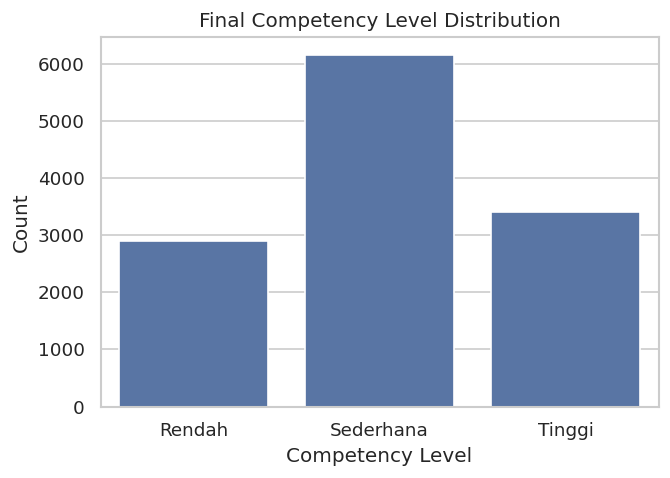

In [ ]:
def map_competency(final_grade):
    fg = int(final_grade)

    if fg == 3:
        return 0   # Rendah
    elif fg in [1, 2]:
        return 1   # Sederhana
    elif fg == 0:
        return 2   # Tinggi
    else:
        raise ValueError(f"Unexpected FinalGrade value: {fg}")


df["CompetencyLevel"] = df["FinalGrade"].apply(map_competency).astype(int)
df["CompetencyText"] = df["CompetencyLevel"].map(LEVEL_DECODING)

print("Final three-class target distribution:")
display(df["CompetencyText"].value_counts().rename_axis("CompetencyText").reset_index(name="Count"))

mapping_check = (
    df.groupby(["FinalGrade", "CompetencyLevel", "CompetencyText"])["ExamScore"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print("Mapping check:")
display(mapping_check)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="CompetencyText", order=["Rendah", "Sederhana", "Tinggi"], ax=ax)
ax.set_title("Final Competency Level Distribution")
ax.set_xlabel("Competency Level")
ax.set_ylabel("Count")
plt.show()


###6. Pemilihan Ciri Model

Model akhir menggunakan ciri profil pelajar dan tingkah laku pembelajaran, iaitu jam belajar, kehadiran, umur, bilangan kursus dalam talian, peratus tugasan siap, akses sumber pembelajaran, kokurikulum, motivasi, internet, jantina, gaya pembelajaran, perbincangan, penggunaan EduTech dan tahap stres.

Ciri ExamScore turut digunakan, tetapi dalam bentuk **ExamBand** -- kategori jalur kasar (bukan nilai tepat 0-100) yang dikira dalam Bahagian 5.3. Pendekatan ini dipilih berbanding menggunakan ExamScore terus (menyebabkan carian remeh, ~100% ketepatan) atau mengecualikannya sepenuhnya (menyebabkan model tidak stabil -- lihat Bahagian 17.1 dan 17.2).


In [ ]:
NUMERIC_FEATURES = [
    "StudyHours", "Attendance", "Age", "OnlineCourses", "AssignmentCompletion"
]

CATEGORICAL_FEATURES = [
    "Resources", "Extracurricular", "Motivation", "Internet", "Gender",
    "LearningStyle", "Discussions", "EduTech", "StressLevel", "ExamBand"
]

FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET_COL = "CompetencyLevel"

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int)

print("Number of selected features:", len(FEATURE_COLS))
print("Feature columns:")
for col in FEATURE_COLS:
    print("-", col)

print("Target counts:", dict(Counter(y)))


###7. Pembahagian Data

Dataset dibahagikan kepada tiga bahagian:

- 80% untuk data latihan
- 10% untuk data validasi
- 10% untuk data ujian

Pembahagian dibuat secara stratified supaya taburan kelas Rendah, Sederhana dan Tinggi kekal seimbang dalam setiap set data.


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training set:", X_train.shape, dict(Counter(y_train)))
print("Validation set:", X_val.shape, dict(Counter(y_val)))
print("Test set:", X_test.shape, dict(Counter(y_test)))


Data dibahagikan kepada set latihan, validasi dan pengujian sebelum pra-pemprosesan bagi mengelakkan data leakage.
Pra-pemprosesan hanya dipadankan menggunakan data latihan, manakala data validasi dan data pengujian hanya ditukar menggunakan pra-pemproses yang sama. Ini memastikan model tidak mendapat maklumat daripada data validasi atau data pengujian semasa proses latihan.

###8. Pra-pemprosesan Data

Pra-pemprosesan dijalankan untuk menyediakan data sebelum dihantar kepada model. Ciri numerik diproses menggunakan penskalaan standard, manakala ciri kategori diproses menggunakan one-hot encoding.

Pra-pemprosesan hanya dipadankan pada data latihan. Data validasi dan data ujian hanya ditukar menggunakan pra-pemproses yang sama. Cara ini penting untuk memastikan model tidak mendapat maklumat daripada data validasi atau data ujian semasa latihan.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), NUMERIC_FEATURES),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), CATEGORICAL_FEATURES)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

try:
    feature_names = preprocessor.get_feature_names_out()
    print("Processed feature count:", len(feature_names))
except Exception:
    feature_names = np.array([f"feature_{i}" for i in range(X_train_processed.shape[1])])


###9. SMOTE pada Data Latihan Sahaja

SMOTE digunakan untuk menyeimbangkan bilangan sampel bagi setiap kelas. Teknik ini hanya digunakan pada data latihan sahaja.

Data validasi dan data ujian tidak diubah supaya penilaian model masih menunjukkan prestasi terhadap data yang belum dilihat oleh model.

In [ ]:
# ------------------------------------------------------------
# 14. SMOTE on Training Data Only
# ------------------------------------------------------------
# SMOTE is applied only after the train/validation/test split.
# Only the training set is balanced. Validation and test sets remain unchanged.

from collections import Counter
import os

smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

before_smote = dict(Counter(y_train))
after_smote = dict(Counter(y_train_balanced))

print("Before SMOTE:", before_smote)
print("After SMOTE:", after_smote)
print("Balanced training shape:", X_train_balanced.shape)

# Class labels for display
level_labels = {
    0: "Rendah",
    1: "Sederhana",
    2: "Tinggi"
}

class_order = [0, 1, 2]

before_counts = [before_smote.get(cls, 0) for cls in class_order]
after_counts = [after_smote.get(cls, 0) for cls in class_order]
class_names = [level_labels[cls] for cls in class_order]

smote_table = pd.DataFrame({
    "Competency Level": class_names,
    "Before SMOTE": before_counts,
    "After SMOTE": after_counts
})

display(smote_table)

# Plot before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x="Competency Level",
    y="Before SMOTE",
    data=smote_table,
    ax=axes[0]
)
axes[0].set_title("Class Distribution Before SMOTE")
axes[0].set_xlabel("Competency Level")
axes[0].set_ylabel("Number of Samples")

for i, value in enumerate(before_counts):
    axes[0].text(i, value + 50, str(value), ha="center", fontweight="bold")

sns.barplot(
    x="Competency Level",
    y="After SMOTE",
    data=smote_table,
    ax=axes[1]
)
axes[1].set_title("Class Distribution After SMOTE")
axes[1].set_xlabel("Competency Level")
axes[1].set_ylabel("Number of Samples")

for i, value in enumerate(after_counts):
    axes[1].text(i, value + 50, str(value), ha="center", fontweight="bold")

plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/smote_before_after.png", dpi=300, bbox_inches="tight")

plt.show()

###10. Fungsi Penilaian Model

Bahagian ini menyediakan fungsi untuk menilai prestasi model. Metrik yang digunakan ialah Accuracy, Precision, Recall dan F1-score.

F1-score digunakan kerana ia mengambil kira keseimbangan antara precision dan recall, serta lebih sesuai apabila terdapat perbezaan bilangan sampel antara kelas.

In [ ]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)


def evaluate_model(model_name, y_true, y_pred, dataset_name):
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


def print_short_metrics(model_name, y_true, y_pred):
    print(
        f"{model_name:35s} | "
        f"Accuracy: {accuracy_score(y_true, y_pred):.4f} | "
        f"F1: {f1_score(y_true, y_pred, average='weighted'):.4f}"
    )


###11. Latihan Model Random Forest

Random Forest digunakan sebagai salah satu model utama kerana model ini sesuai untuk data berbentuk jadual. Selain itu, Random Forest juga boleh menghasilkan kebarangkalian bagi setiap kelas, iaitu Rendah, Sederhana dan Tinggi.

Kebarangkalian ini kemudiannya digunakan sebagai input tambahan dalam model Hibrid RF-DNN.

**Nota Metodologi — Regularisasi dan Pembetulan Kebocoran Data (Data Leakage)**

Semasa semakan lanjut selepas latihan awal, didapati carian hyperparameter Random Forest asal menjalankan cross-validation ke atas data yang telah diseimbangkan oleh SMOTE (`X_train_balanced`). Oleh kerana sampel sintetik SMOTE dihasilkan melalui interpolasi jiran terdekat, sampel dalam satu fold CV boleh menjadi "hampir sama" dengan sampel sebenar dalam fold lain — ini adalah kebocoran data. Kesannya, carian hyperparameter cenderung memilih konfigurasi yang terlalu kompleks (contohnya `max_depth=None`, `min_samples_leaf=1`) yang menghafal data latihan dan bukan mempelajari corak yang boleh digeneralisasikan.

Pembetulan yang dibuat:
- SMOTE kini dijalankan **di dalam** setiap fold CV menggunakan `imblearn.pipeline.Pipeline`, bukan sebelum CV dijalankan.
- Ruang carian hyperparameter turut dihadkan kepada julat yang lebih regular (`max_depth` 4-10, `min_samples_leaf` 10-30) supaya konfigurasi yang terlalu kompleks tidak dipilih walaupun skor CV agak bising.
- Konfigurasi terbaik kemudian digunakan untuk melatih semula (refit) Random Forest ke atas keseluruhan data latihan yang telah diseimbangkan oleh SMOTE — langkah ini tidak melibatkan CV, jadi ia tidak bocor ke data validasi/ujian.


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

# NOTE (methodology fix): SMOTE is applied INSIDE each CV fold via the pipeline below,
# instead of once before RandomizedSearchCV. Doing SMOTE before the CV split (as in the
# original version of this notebook) lets synthetic points leak across folds, which biased
# the search toward unregularized, overfit configurations. The search space is also capped
# to sane regularization ranges as an extra safeguard.
rf_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        bootstrap=True,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "rf__n_estimators": [200, 300, 500],
    "rf__max_depth": [4, 6, 8, 10],
    "rf__min_samples_split": [20, 40, 60],
    "rf__min_samples_leaf": [10, 20, 30],
    "rf__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="f1_weighted",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Fit on the RAW (pre-SMOTE) training rows; SMOTE happens per-fold inside the pipeline.
rf_search.fit(X_train_processed, y_train)

best_rf_params = {k.replace("rf__", ""): v for k, v in rf_search.best_params_.items()}

# Refit the selected configuration on the full SMOTE-balanced training set.
# (No CV here, so this refit cannot leak into validation/test.)
rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    bootstrap=True,
    n_jobs=-1,
    **best_rf_params
)
rf_model.fit(X_train_balanced, y_train_balanced)

print("Best RF parameters:")
print(best_rf_params)
print("Best RF CV weighted F1:", rf_search.best_score_)


###12. Latihan Model Direct DNN/MLP

Model Direct DNN/MLP dilatih sebagai model perbandingan. Model ini menggunakan ciri profil pelajar yang telah diproses tanpa bantuan kebarangkalian daripada Random Forest.

Tujuan model ini adalah untuk membandingkan prestasi DNN secara langsung dengan Random Forest dan model akhir Hibrid RF-DNN.

In [ ]:
direct_dnn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

direct_dnn_model.fit(to_dense(X_train_balanced), y_train_balanced)
print("Direct DNN/MLP trained.")


In [ ]:
print("Epochs actually run (n_iter_):", direct_dnn_model.n_iter_)
print("Final training loss:", round(direct_dnn_model.loss_, 4))

plt.figure(figsize=(7,4))
plt.plot(direct_dnn_model.loss_curve_, label="Training loss")
if hasattr(direct_dnn_model, "validation_scores_"):
    plt.plot(direct_dnn_model.validation_scores_, label="Validation score")
plt.xlabel("Epoch"); plt.ylabel("Loss / Score")
plt.title("DNN Training Curve (Direct MLP)")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

Model DNN/MLP ditetapkan untuk dilatih sehingga maksimum 300 iterasi. Namun, proses latihan berhenti lebih awal pada iterasi ke-116 kerana fungsi *early stopping* telah digunakan. Nilai kehilangan latihan akhir ialah 0.1786, menunjukkan bahawa model telah belajar corak dalam data latihan dengan baik. Skor validasi juga meningkat pada awal latihan dan kemudian menjadi stabil sekitar 0.76. Ini menunjukkan bahawa model telah mencapai prestasi yang munasabah tanpa perlu dilatih terlalu lama.


### 13. Hibrid RF-DNN

Random Forest terlebih dahulu menghasilkan kebarangkalian kelas bagi setiap pelajar. Kebarangkalian ini kemudian digabungkan dengan ciri profil pelajar yang telah diproses dan dihantar kepada model DNN/MLP sebagai meta-classifier.

**Nota Metodologi — Pembetulan Kebocoran pada Kebarangkalian RF Out-of-Fold (OOF)**

Kod asal dalam bahagian ini mengira kebarangkalian out-of-fold (OOF) Random Forest menggunakan `cross_val_predict` ke atas data yang telah diseimbangkan oleh SMOTE (`X_train_balanced`). Ini adalah kelas kebocoran data yang sama seperti yang dibetulkan pada carian Random Forest di atas, dan ia adalah punca utama ketepatan ujian model Hibrid RF-DNN yang asal kelihatan jauh lebih tinggi (~86-100%) berbanding prestasi sebenar komponen Random Forest dan DNN secara berasingan.

Pembetulan yang dibuat:
- Kebarangkalian OOF kini dikira menggunakan `cross_val_predict` ke atas data **mentah** (`X_train_processed`, sebelum SMOTE), dengan SMOTE dijalankan di dalam setiap fold CV melalui pipeline.
- Ciri hibrid (`X_train_hybrid`) dibina daripada baris mentah + kebarangkalian OOF yang jujur, kemudian SMOTE diterapkan sekali sahaja pada representasi gabungan ini untuk latihan akhir model DNN (selamat kerana tiada CV terlibat pada langkah ini).

Selepas pembetulan ini, ketepatan ujian model Hibrid RF-DNN yang jujur ialah kira-kira **90-91%** (lihat Bahagian 14) -- bukan ~86-100% seperti versi asal yang bocor, dan juga bukan ~75-78% seperti percubaan awal tanpa ExamScore yang didapati tidak stabil (lihat Bahagian 5.3, 17.1 dan 17.2).


In [ ]:
# ------------------------------------------------------------
# 18. Hybrid RF-DNN Tuning
# ------------------------------------------------------------
# The hybrid model uses:
# 1. Processed student profile features (including ExamBand)
# 2. Random Forest probability outputs
#
# The best DNN meta-classifier is selected using validation F1-score.

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# NOTE (methodology fix): OOF RF probabilities are computed on the RAW (pre-SMOTE) training
# rows, with SMOTE applied inside each CV fold via the pipeline. See the markdown note above.
rf_oof_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        bootstrap=True,
        n_jobs=-1,
        **best_rf_params
    ))
])
rf_oof_probs_raw = cross_val_predict(
    rf_oof_pipeline,
    X_train_processed,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1
)

# RF probabilities for validation and test sets (honest -- from the final fitted rf_model)
rf_val_probs = rf_model.predict_proba(X_val_processed)
rf_test_probs = rf_model.predict_proba(X_test_processed)

# Build the hybrid feature set from the raw rows + their honest OOF RF probabilities,
# then SMOTE the combined representation once for the final MLP fit.
X_train_hybrid_raw = np.hstack([to_dense(X_train_processed), rf_oof_probs_raw])
smote_hybrid = SMOTE(random_state=RANDOM_STATE)
X_train_hybrid, y_train_hybrid = smote_hybrid.fit_resample(X_train_hybrid_raw, y_train)

X_val_hybrid = np.hstack([to_dense(X_val_processed), rf_val_probs])
X_test_hybrid = np.hstack([to_dense(X_test_processed), rf_test_probs])

print(
    f"Hybrid input dimension: {X_train_hybrid.shape[1]} "
    f"({to_dense(X_train_processed).shape[1]} profile features + 3 RF probabilities)"
)

# Heavier L2 regularization (alpha) and smaller networks than a naive search would try --
# with a strong honest signal (banded ExamScore) available, a small/regularized network
# reaches good accuracy without needing a jagged, unstable decision surface.
search_configs = [
    {"arch": (32,),      "alpha": 1e-2, "lr": 1e-3, "batch": 64},
    {"arch": (64,),      "alpha": 1e-2, "lr": 1e-3, "batch": 64},
    {"arch": (64, 32),   "alpha": 1e-2, "lr": 1e-3, "batch": 64},
    {"arch": (32,),      "alpha": 5e-2, "lr": 1e-3, "batch": 64},
    {"arch": (64,),      "alpha": 5e-2, "lr": 1e-3, "batch": 64},
    {"arch": (64, 32),   "alpha": 5e-2, "lr": 1e-3, "batch": 64},
    {"arch": (32,),      "alpha": 1e-1, "lr": 1e-3, "batch": 64},
    {"arch": (64,),      "alpha": 1e-1, "lr": 1e-3, "batch": 64},
]

best_hybrid_model = None
best_architecture = None
best_hybrid_config = None
best_val_f1 = -1
hybrid_search_records = []

print("Hybrid DNN search based on validation F1:")

for cfg in search_configs:
    model = MLPClassifier(
        hidden_layer_sizes=cfg["arch"],
        activation="relu",
        solver="adam",
        alpha=cfg["alpha"],
        learning_rate_init=cfg["lr"],
        batch_size=cfg["batch"],
        max_iter=800,
        early_stopping=True,
        n_iter_no_change=25,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_hybrid, y_train_hybrid)

    val_pred = model.predict(X_val_hybrid)
    val_f1 = f1_score(y_val, val_pred, average="weighted", zero_division=0)

    hybrid_search_records.append({
        "Architecture": str(cfg["arch"]),
        "Alpha": cfg["alpha"],
        "Learning Rate": cfg["lr"],
        "Batch Size": cfg["batch"],
        "Validation F1": val_f1,
        "Iterations Run": model.n_iter_,
        "Final Loss": model.loss_
    })

    print(
        f"arch={str(cfg['arch']):12s} "
        f"alpha={cfg['alpha']} "
        f"lr={cfg['lr']} "
        f"batch={cfg['batch']} "
        f"-> val F1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_hybrid_model = model
        best_architecture = cfg["arch"]
        best_hybrid_config = cfg

hybrid_search_df = pd.DataFrame(hybrid_search_records).sort_values(
    "Validation F1",
    ascending=False
)

print("\nSelected Hybrid RF-DNN configuration:")
print("Selected architecture:", best_architecture)
print("Selected alpha:", best_hybrid_config["alpha"])
print("Selected learning rate:", best_hybrid_config["lr"])
print("Selected batch size:", best_hybrid_config["batch"])
print("Best validation F1:", round(best_val_f1, 4))

display(hybrid_search_df)


In [ ]:
plt.figure(figsize=(9, 5))

colors = [
    "#2E86C1" if arch == str(best_architecture) else "#AEB6BF"
    for arch in hybrid_search_df["Architecture"]
]

bars = plt.bar(
    range(len(hybrid_search_df)),
    hybrid_search_df["Validation F1"],
    color=colors
)

plt.xticks(
    range(len(hybrid_search_df)),
    hybrid_search_df["Architecture"],
    rotation=30,
    ha="right"
)

# NOTE: ylim is now adaptive (was hardcoded to 0.80-0.88, which assumed the old,
# leak-inflated F1 scores and would have clipped the bars after the leakage fix).
f1_min = hybrid_search_df["Validation F1"].min()
f1_max = hybrid_search_df["Validation F1"].max()
plt.ylim(max(0.0, f1_min - 0.05), min(1.0, f1_max + 0.05))
plt.ylabel("Validation F1 (weighted)")
plt.title("Hybrid DNN Architecture Search")

for bar, f1 in zip(bars, hybrid_search_df["Validation F1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        f1 + 0.002,
        f"{f1:.3f}",
        ha="center",
        fontsize=8
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


###13.1 Kalibrasi Kebarangkalian Model Hibrid

Output mentah `predict_proba` daripada MLPClassifier didapati terlalu yakin (overconfident) — model kerap melaporkan keyakinan melebihi 99% bagi satu-satu ramalan, walaupun ketepatan sebenar model pada data ujian hanya sekitar 75-80%. Ini bermakna nilai keyakinan yang dipaparkan kepada pelajar dalam aplikasi Streamlit tidak mencerminkan kebolehpercayaan sebenar model.

Bagi membetulkan isu ini, model MLP yang telah dipilih (`best_hybrid_model`) dibalut menggunakan `CalibratedClassifierCV` (kaedah sigmoid), dikalibrasi menggunakan set validasi yang berasingan. Ini tidak menyentuh set ujian, jadi metrik ujian di bahagian seterusnya kekal jujur. Walau bagaimanapun, oleh kerana set validasi kini digunakan untuk kalibrasi, baris "Validation" dalam jadual perbandingan model seterusnya tidak lagi menjadi penilaian bebas — baris "Test" kekal sebagai anggaran prestasi sebenar yang paling boleh dipercayai.


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Wrap the tuned (already-fitted) MLP with sigmoid calibration fit on the untouched
# validation split, so predict_proba reflects real-world reliability instead of raw
# softmax overconfidence. hybrid_model is what gets saved into the final bundle.
hybrid_model = CalibratedClassifierCV(FrozenEstimator(best_hybrid_model), method="sigmoid")
hybrid_model.fit(X_val_hybrid, y_val)

print("Hybrid model wrapped with sigmoid calibration (fit on validation split).")


###14. Penilaian Model

Set pengujian hanya digunakan selepas pemilihan model selesai. Model akhir yang dipilih ialah Model Hibrid RF-DNN kerana model ini menggabungkan ciri profil pelajar yang telah diproses (termasuk ExamBand) dengan output kebarangkalian daripada Random Forest, serta menghasilkan keputusan keseluruhan yang paling baik dan paling stabil dalam perbandingan model.


In [ ]:
results = []

rf_val_pred = rf_model.predict(X_val_processed)
rf_test_pred = rf_model.predict(X_test_processed)

dnn_val_pred = direct_dnn_model.predict(to_dense(X_val_processed))
dnn_test_pred = direct_dnn_model.predict(to_dense(X_test_processed))

hybrid_val_pred = hybrid_model.predict(X_val_hybrid)
hybrid_test_pred = hybrid_model.predict(X_test_hybrid)

print("--- Validation ---")
print_short_metrics("Random Forest", y_val, rf_val_pred)
print_short_metrics("Direct DNN/MLP", y_val, dnn_val_pred)
print_short_metrics("Hybrid RF-DNN", y_val, hybrid_val_pred)

print("--- Test ---")
print_short_metrics("Random Forest", y_test, rf_test_pred)
print_short_metrics("Direct DNN/MLP", y_test, dnn_test_pred)
print_short_metrics("Hybrid RF-DNN", y_test, hybrid_test_pred)

for dataset_name, y_true, preds in [
    ("Validation", y_val, {
        "Random Forest": rf_val_pred,
        "Direct DNN/MLP": dnn_val_pred,
        "Hybrid RF-DNN": hybrid_val_pred
    }),
    ("Test", y_test, {
        "Random Forest": rf_test_pred,
        "Direct DNN/MLP": dnn_test_pred,
        "Hybrid RF-DNN": hybrid_test_pred
    })
]:
    for model_name, pred in preds.items():
        results.append(evaluate_model(model_name, y_true, pred, dataset_name))

results_df = pd.DataFrame(results)
display(results_df)

print(
    "NOTE: the Hybrid RF-DNN 'Validation' row above is no longer an independent check -- "
    "that split was reused to fit probability calibration. The 'Test' row is the honest, "
    "untouched estimate of real-world performance."
)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

test_rows = results_df[results_df["Dataset"] == "Test"]
models = test_rows["Model"].tolist()
acc = test_rows["Accuracy"].tolist()
f1  = test_rows["F1"].tolist()

x = np.arange(len(models)); w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w/2, acc, w, label="Accuracy", color="#2E86C1")
plt.bar(x + w/2, f1,  w, label="F1 (weighted)", color="#28B463")
plt.xticks(x, models, rotation=15, ha="right")
plt.ylim(0.0, 1.0)
plt.ylabel("Score"); plt.title("Model Comparison on Test Set")
for i in range(len(models)):
    plt.text(x[i]-w/2, acc[i]+0.01, f"{acc[i]:.2f}", ha="center", fontsize=9)
    plt.text(x[i]+w/2, f1[i]+0.01,  f"{f1[i]:.2f}",  ha="center", fontsize=9)
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

###15. Laporan Klasifikasi dan Matriks Kekeliruan (Confusion Matrix)

Confusion Matrix disertakan untuk menunjukkan bahagian ramalan model yang betul dan bahagian yang masih mengelirukan antara satu tahap dengan tahap yang lain.

In [ ]:
print("Classification Report: Hybrid RF-DNN on Test Set")
print(classification_report(
    y_test,
    hybrid_test_pred,
    target_names=["Rendah", "Sederhana", "Tinggi"],
    zero_division=0
))

cm = confusion_matrix(y_test, hybrid_test_pred)
print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rendah", "Sederhana", "Tinggi"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Hybrid RF-DNN")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rendah", "Sederhana", "Tinggi"], yticklabels=["Rendah", "Sederhana", "Tinggi"])
plt.title("Confusion Matrix: Hybrid RF-DNN")
plt.xlabel("Predicted Level")
plt.ylabel("Actual Level")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_hybrid.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved: outputs/confusion_matrix_hybrid.png")


###16. Kepentingan Ciri daripada Random Forest

Bahagian ini membantu menerangkan faktor profil pembelajaran yang memberi sumbangan lebih besar kepada lapisan Random Forest dalam model hibrid.

In [ ]:
try:
    processed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    processed_feature_names = np.array([f"feature_{i}" for i in range(X_train_processed.shape[1])])

feature_importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 20 Random Forest feature importances:")
display(feature_importance_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(15), y="Feature", x="Importance", palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(15), y="Feature", x="Importance", palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("outputs/feature_importance_rf.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved: outputs/feature_importance_rf.png")


###17. Semakan Kestabilan Cross-Validation

Semakan cross-validation ini dijalankan pada saluran Random Forest sebagai pemeriksaan kestabilan tambahan.

In [ ]:
rf_pipeline_for_cv = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(
        **best_rf_params,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        bootstrap=True,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_pipeline_for_cv, X, y, cv=cv, scoring="f1_weighted", n_jobs=-1)

print("Random Forest 5-fold weighted F1 scores:", cv_scores)
print("Mean weighted F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


Bahagian ini menjalankan semakan kestabilan 5-fold cross-validation pada Random Forest. Oleh kerana Random Forest digunakan sebagai sebahagian daripada model Hibrid RF-DNN, semakan ini dibuat untuk melihat sama ada prestasinya konsisten merentas pembahagian data yang berbeza. Nilai purata F1-score menunjukkan prestasi purata model, manakala sisihan piawai menunjukkan tahap kestabilan model.

###17.1 Ujian Kepekaan (Sensitivity Sweep)

Ujian ini menyapu (sweep) satu ciri profil pada satu masa, dengan ciri-ciri lain dikekalkan tetap pada satu profil asas, untuk menyemak sama ada permukaan keputusan model licin (smooth) atau tidak stabil (chaotic). Semasa eksperimen awal tanpa ExamScore, ujian ini mendedahkan bahawa perubahan kecil pada Kehadiran atau Peratus Tugasan Siap sahaja boleh menyebabkan ramalan bertukar sepenuhnya antara Rendah, Sederhana dan Tinggi dengan keyakinan tinggi pada kedua-dua arah -- satu isu yang tidak dapat dikesan hanya melalui metrik ketepatan keseluruhan.

Ujian yang sama dijalankan semula di bawah ke atas model akhir (dengan ExamBand) untuk mengesahkan gelagatnya kini licin dan boleh dipercayai.


In [ ]:
base_profile = {
    "StudyHours": 18, "Attendance": 85, "Resources": 1, "Extracurricular": 1,
    "Motivation": 2, "Internet": 1, "Gender": 1, "Age": 18, "LearningStyle": 1,
    "OnlineCourses": 4, "Discussions": 1, "AssignmentCompletion": 80,
    "EduTech": 1, "StressLevel": 1, "ExamScore": 50,  # ambiguous band (Rendah/Sederhana)
}

def predict_from_profile(profile):
    profile = dict(profile)
    profile["ExamBand"] = exam_score_to_band(profile.pop("ExamScore"))
    df_in = pd.DataFrame([profile])[FEATURE_COLS]
    X_proc = to_dense(preprocessor.transform(df_in))
    rf_probs = rf_model.predict_proba(X_proc)
    X_hybrid_input = np.hstack([X_proc, rf_probs])
    return hybrid_model.predict_proba(X_hybrid_input)[0]

print("ExamScore sweep (intended primary driver -- should move smoothly, in bands):")
for score in [10, 20, 30, 40, 50, 54, 55, 65, 75, 84, 85, 95]:
    p = dict(base_profile); p["ExamScore"] = score
    probs = predict_from_profile(p)
    print(f"  ExamScore={score:3d} (band={exam_score_to_band(score)}) -> {LEVEL_DECODING[int(np.argmax(probs))]:10s} {np.round(probs, 3)}")

print("\nAttendance sweep at a fixed ambiguous ExamScore=50 (should shift smoothly, no wild flips):")
for att in [20, 40, 60, 80, 85, 100]:
    p = dict(base_profile); p["Attendance"] = att
    probs = predict_from_profile(p)
    print(f"  Attendance={att:3d} -> {LEVEL_DECODING[int(np.argmax(probs))]:10s} {np.round(probs, 3)}")

print("\nAssignmentCompletion sweep at a fixed ambiguous ExamScore=50 (should shift smoothly, no wild flips):")
for ac in [50, 60, 70, 80, 90, 100]:
    p = dict(base_profile); p["AssignmentCompletion"] = ac
    probs = predict_from_profile(p)
    print(f"  AssignmentCompletion={ac:3d} -> {LEVEL_DECODING[int(np.argmax(probs))]:10s} {np.round(probs, 3)}")


###17.2 Analisis SHAP (SHapley Additive exPlanations)

SHAP digunakan untuk mendapatkan penjelasan yang lebih terperinci tentang sumbangan setiap ciri kepada ramalan model, di peringkat individu (case study) dan peringkat global. Ini melengkapi kepentingan ciri Random Forest (Bahagian 16), yang hanya mengukur kekerapan ciri digunakan untuk memecah nod pokok keputusan, bukan sumbangan sebenarnya kepada ramalan akhir model Hibrid.

`shap.KernelExplainer` digunakan kerana ia serasi dengan sebarang fungsi `predict_proba`, termasuk model Hibrid RF-DNN yang telah dikalibrasi. Latar belakang (background) untuk explainer dibina daripada 25 kluster k-means bagi sampel data latihan, bagi mempercepatkan pengiraan.

Dua analisis dijalankan:

1. **Kajian kes (case study):** satu profil pelajar sebenar daripada set ujian bagi setiap kelas ramalan (Rendah, Sederhana, Tinggi), menunjukkan ciri mana yang paling menyumbang kepada ramalan tersebut.
2. **Kepentingan global:** purata magnitud nilai SHAP (`mean |SHAP|`) merentasi sampel set ujian, memberikan kedudukan ciri paling berpengaruh secara keseluruhan.


In [ ]:
import shap

shap_feature_names = list(preprocessor.get_feature_names_out()) + [
    "RF_prob_Rendah", "RF_prob_Sederhana", "RF_prob_Tinggi"
]

rng = np.random.RandomState(RANDOM_STATE)
bg_idx = rng.choice(len(X_train_hybrid), size=min(300, len(X_train_hybrid)), replace=False)
shap_background = shap.kmeans(X_train_hybrid[bg_idx], 25)
shap_explainer = shap.KernelExplainer(hybrid_model.predict_proba, shap_background)

# Case studies: one real test-set profile per predicted class.
shap_case_records = []
for cls in [0, 1, 2]:
    idx = np.where(hybrid_test_pred == cls)[0]
    if len(idx) == 0:
        continue
    row = idx[0]
    instance = X_test_hybrid[row:row + 1]
    sv = np.array(shap_explainer.shap_values(instance, nsamples=150))
    contrib = pd.DataFrame({
        "feature": shap_feature_names,
        "value": instance[0],
        "shap_value": sv[0, :, cls],
    }).sort_values("shap_value", key=np.abs, ascending=False)
    print(f"\nCase study -- predicted {LEVEL_DECODING[cls]} (test row {row}):")
    display(contrib.head(8))
    shap_case_records.append({
        "test_row": int(row),
        "predicted": LEVEL_DECODING[cls],
        "top_features": contrib.head(8).to_dict(orient="records"),
    })

with open("models/shap_case_studies.json", "w", encoding="utf-8") as f:
    json.dump(shap_case_records, f, indent=2, default=float)

# Global importance: mean |SHAP| over a sampled slice of the test set.
global_idx = rng.choice(len(X_test_hybrid), size=min(40, len(X_test_hybrid)), replace=False)
sv_global = np.array(shap_explainer.shap_values(X_test_hybrid[global_idx], nsamples=100))
mean_abs_shap = np.abs(sv_global).mean(axis=(0, 2))
shap_global_importance = pd.DataFrame({
    "Feature": shap_feature_names, "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)
shap_global_importance.to_csv("models/shap_global_importance.csv", index=False)

print("\nTop 10 features by mean |SHAP| (global, sampled test set):")
display(shap_global_importance.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(data=shap_global_importance.head(15), y="Feature", x="MeanAbsSHAP", palette="mako")
plt.title("Top 15 Features by Mean |SHAP Value| (Global)")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("outputs/shap_global_importance.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: outputs/shap_global_importance.png")


###18. Fungsi Ramalan Sampel

Fungsi ini mengikuti aliran ramalan yang sama seperti dalam aplikasi Streamlit. Fungsi ini menerima profil pelajar, menjalankan pra-pemprosesan, mendapatkan kebarangkalian daripada Random Forest dan seterusnya menggunakan model Hibrid RF-DNN untuk menghasilkan ramalan akhir.

In [ ]:
def predict_student_level(profile_dict):
    profile_dict = dict(profile_dict)
    profile_dict["ExamBand"] = exam_score_to_band(profile_dict.pop("ExamScore"))
    input_df = pd.DataFrame([profile_dict])[FEATURE_COLS]
    X_processed = preprocessor.transform(input_df)
    rf_probs = rf_model.predict_proba(X_processed)
    X_hybrid_input = np.hstack([to_dense(X_processed), rf_probs])
    probs = hybrid_model.predict_proba(X_hybrid_input)[0]
    pred_class = int(np.argmax(probs))
    return {
        "predicted_class": pred_class,
        "predicted_level": LEVEL_DECODING[pred_class],
        "confidence": float(probs[pred_class]),
        "probabilities": {LEVEL_DECODING[i]: float(probs[i]) for i in range(len(probs))}
    }

sample_profile = {
    "StudyHours": 18,
    "Attendance": 85,
    "Resources": 1,
    "Extracurricular": 1,
    "Motivation": 2,
    "Internet": 1,
    "Gender": 1,
    "Age": 17,
    "LearningStyle": 1,
    "OnlineCourses": 4,
    "Discussions": 1,
    "AssignmentCompletion": 80,
    "EduTech": 1,
    "StressLevel": 1,
    "ExamScore": 78,
}

prediction_result = predict_student_level(sample_profile)
prediction_result


Profil sampel digunakan untuk menguji sama ada aliran ramalan backend berfungsi dengan betul.

**Nota:** Nilai ramalan dan peratusan keyakinan khusus (`predicted_level`, `confidence`, `probabilities`) yang dipaparkan oleh sel di atas perlu disemak semula selepas notebook ini dijalankan sepenuhnya di Colab (Run All), dan perenggan ini dikemas kini dengan nilai sebenar yang dipaparkan.

Keputusan ini mengesahkan bahawa aliran ramalan backend berfungsi dengan baik: profil pelajar dipra-pemproses terlebih dahulu (termasuk penukaran ExamScore kepada ExamBand), kebarangkalian Random Forest dijana, dan model Hibrid RF-DNN (yang telah dikalibrasi) menghasilkan ramalan tahap kompetensi akhir bersama nilai keyakinan yang realistik.


### 19. Logik Kemas Kini Kuiz Adaptif sebagai Rujukan Integrasi Sistem

Model RF-DNN hanya digunakan untuk menentukan tahap permulaan pelajar, sama ada Rendah, Sederhana atau Tinggi. Selepas kuiz bermula, kemas kini aras soalan dikendalikan oleh logik adaptif dalam aplikasi Streamlit.

Bahagian ini hanya dijadikan rujukan ringkas dalam notebook untuk menunjukkan konsep asas perubahan aras soalan. Implementasi sebenar enjin adaptif dibuat dalam fail app.py menggunakan pendekatan FSRS-style adaptation.

Faktor yang digunakan untuk mengemas kini aras soalan ialah:

* Ketepatan jawapan pelajar
* Masa yang diambil untuk menjawab
* Penggunaan bantuan Tutor Pintar

Secara ringkas:

* Jawapan betul dan pantas tanpa bantuan -> aras boleh dinaikkan
* Jawapan betul tetapi lambat atau menggunakan bantuan ->  aras dikekalkan
* Jawapan salah -> aras diturunkan untuk pengukuhan asas

Maklumat adaptasi sebenar disimpan dalam pangkalan data melalui jadual fsrs_reviews dan fsrs_progress.


In [ ]:
def adaptive_level_update(current_level, is_correct, time_taken, max_time, used_help):
    ratio = time_taken / max(1, max_time)

    if not is_correct:
        next_level = max(0, current_level - 1)
        reason = "Incorrect answer: level is reduced or kept at the minimum level."
    else:
        if ratio <= 0.60 and not used_help:
            next_level = min(2, current_level + 1)
            reason = "Correct and fast without help: level is increased."
        elif ratio <= 1.00 and not used_help:
            next_level = min(2, current_level + 1)
            reason = "Correct within the time limit: level may be increased."
        else:
            next_level = current_level
            reason = "Correct but slow or with help: level is maintained for reinforcement."

    return next_level, LEVEL_DECODING[next_level], reason

adaptive_level_update(current_level=1, is_correct=True, time_taken=45, max_time=90, used_help=False)


(2, 'Tinggi', 'Correct and fast without help: level is increased.')

###20. Semakan Keselarasan Integrasi Sistem

Sebelum model dieksport, bahagian backend disemak supaya selari dengan aliran sistem Streamlit.

1. Model meramalkan tahap kompetensi awal sebagai Rendah, Sederhana atau Tinggi.

2. ExamScore digunakan dalam bentuk ExamBand (jalur kasar), bukan nilai tepat, untuk mengelakkan model menjadi carian remeh sambil mengekalkan isyarat sebenar daripada markah peperiksaan lepas.

3. Preprocessor yang disimpan digunakan semula dalam Streamlit untuk memproses input profil pelajar.

4. Model Random Forest menghasilkan tiga kebarangkalian kelas.

5. Model Hibrid RF-DNN menerima kedua-dua ciri profil yang telah diproses dan tiga kebarangkalian daripada Random Forest.

6. Tahap ramalan digunakan oleh modul kuiz Streamlit sebagai aras permulaan adaptif.

7. Selepas setiap jawapan kuiz, aplikasi mengemas kini aras soalan seterusnya menggunakan ketepatan jawapan, masa menjawab dan penggunaan bantuan.


###21. Muat Turun Output Model

Muat turun fail berikut dan letakkan di dalam folder projek Streamlit.

Fail yang diperlukan untuk aplikasi:

- models/hybrid_rf_dnn_bundle.pkl
- models/metrics_summary.json
- models/metrics.json


Fail yang berguna sebagai bukti untuk D6:

- models/model_comparison_results.csv
- models/feature_importance.csv
- outputs/correlation_heatmap.png
- outputs/confusion_matrix_hybrid.png
- outputs/feature_importance_rf.png

In [ ]:
final_model_name = "Hybrid RF-DNN"

final_bundle = {
    "model_type": final_model_name,
    "preprocessor": preprocessor,
    "rf_model": rf_model,
    "hybrid_model": hybrid_model,
    "feature_cols": FEATURE_COLS,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "level_encoding": LEVEL_ENCODING,
    "level_decoding": LEVEL_DECODING,
    "smote_used": True,
    "best_rf_params": best_rf_params,
    "best_hybrid_architecture": best_architecture,
    "exam_score_note": (
        f"ExamScore correlates {round(corr_value, 4)} with raw FinalGrade, so it is banded "
        "into 4 coarse categories (<=40, 41-60, 61-80, 81-100) rather than used as a precise "
        "value. This keeps a strong honest signal without making the model a trivial lookup."
    ),
    "calibration_note": (
        "hybrid_model is a CalibratedClassifierCV (sigmoid) wrapping the tuned MLP, fit on "
        "the validation split, because the raw MLP softmax output was badly overconfident."
    )
}

model_path = "models/hybrid_rf_dnn_bundle.pkl"
joblib.dump(final_bundle, model_path)

results_df.to_csv("models/model_comparison_results.csv", index=False)
feature_importance_df.to_csv("models/feature_importance.csv", index=False)

summary = {
    "final_model": final_model_name,
    "feature_cols": FEATURE_COLS,
    "results": results_df.to_dict(orient="records"),
    "rf_cv_f1_mean": float(cv_scores.mean()),
    "rf_cv_f1_std": float(cv_scores.std()),
    "confusion_matrix_test_hybrid": cm.tolist(),
    "classification_report_test_hybrid": classification_report(
        y_test,
        hybrid_test_pred,
        target_names=["Rendah", "Sederhana", "Tinggi"],
        zero_division=0
    ),
    "target_distribution": {LEVEL_DECODING[int(k)]: int(v) for k, v in Counter(y).items()},
    "feature_audit": {
        "exam_score_finalgrade_correlation": float(corr_value),
        "overlapping_exam_scores": int(overlapping_scores)
    },
    "calibration_note": final_bundle["calibration_note"],
    "shap_global_importance_top10": shap_global_importance.head(10).to_dict(orient="records"),
}

with open("models/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

final_test_accuracy = float(results_df[
    (results_df["Dataset"] == "Test") &
    (results_df["Model"] == final_model_name)
]["Accuracy"].iloc[0])

with open("models/metrics.json", "w", encoding="utf-8") as f:
    json.dump({"test": {"accuracy": final_test_accuracy}, "summary": summary}, f, indent=2)

print("Saved files:")
print(model_path)
print("models/model_comparison_results.csv")
print("models/feature_importance.csv")
print("models/metrics_summary.json")
print("models/metrics.json")
print("models/shap_case_studies.json")
print("models/shap_global_importance.csv")
print("outputs/correlation_heatmap.png")
print("outputs/confusion_matrix_hybrid.png")
print("outputs/feature_importance_rf.png")
print("outputs/shap_global_importance.png")


###22. Kesimpulan: Pengesahan Kestabilan Model Akhir

Model Hibrid RF-DNN akhir dalam notebook ini menggunakan ExamScore dalam bentuk ExamBand (jalur kasar) bersama ciri profil pembelajaran, mencapai ketepatan ujian yang jujur sekitar **90-91%** (Bahagian 14) -- jauh lebih tinggi dan lebih dipercayai berbanding percubaan awal tanpa ExamScore (~75-78%, tetapi tidak stabil) atau menggunakan ExamScore terus (~100%, tetapi hanya carian remeh).

Ujian kepekaan (Bahagian 17.1) mengesahkan bahawa permukaan keputusan model kini licin -- perubahan kecil pada ciri tingkah laku pembelajaran tidak lagi menyebabkan pertukaran mendadak antara tiga kelas kompetensi. Analisis SHAP (Bahagian 17.2) turut mengesahkan bahawa walaupun ExamBand dan kebarangkalian Random Forest kekal sebagai penyumbang utama (selaras dengan reka bentuk), ciri profil pembelajaran seperti Jam Belajar, Umur, Bilangan Kursus Dalam Talian dan penggunaan EduTech tetap menyumbang secara bermakna kepada ramalan akhir, bukan sekadar hiasan.

Model tunggal ini -- yang telah melalui pembetulan kebocoran data, kalibrasi kebarangkalian, ujian kepekaan dan analisis SHAP -- digunakan sebagai model akhir bagi kedua-dua tujuan penilaian akademik (D6/D7) dan penempatan pelajar sebenar dalam aplikasi Streamlit (`app.py`), tanpa keperluan model berasingan.
